In [ ]:
!pip install ultralytics easyocr opencv-python

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO('/content/drive/MyDrive/capstone/license-plate-finetune-v1l.pt')
results = model.predict('/content/drive/MyDrive/yolo_fuck/images/val/track0061[03].png', save = False)


image 1/1 /content/drive/MyDrive/yolo_fuck/images/val/track0061[03].png: 384x640 1 License_Plate, 31.9ms
Speed: 2.2ms preprocess, 31.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
import cv2
def to_grey(img):
  return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
def results_to_cv2(results):
    return results[0].plot().copy()
def show_img(cv2_results):
    h, w = cv2_results.shape[:2]
    plt.figure(figsize=(w/100, h/100))  # scale properly
    plt.imshow(cv2.cvtColor(cv2_results, cv2.COLOR_BGR2RGB))  # convert to RGB
    plt.axis('off')
    plt.show()

def get_cords_conf(yolo_results):
  result = yolo_results[0]              # first image result
  boxes = result.boxes             # Boxes object
  return boxes.xyxy.cpu().numpy().tolist(), boxes.conf.cpu().numpy().tolist()

def crop_img(img, cords):
  x1, y1, x2, y2 = cords
  return img[y1:y2, x1:x2]


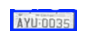

In [ ]:
from math import floor
img = results_to_cv2(results)
cords, conf = get_cords_conf(results)
n = [floor(i) for i in cords[0]]
crop = crop_img(img, n)
img = crop.copy()
show_img(crop)

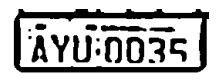

In [ ]:
def pipe_plate_topline(img_bgr):
    """
    img_bgr: original image in BGR (cv2.imread) or equivalent.
    Returns a binary image suitable for OCR.
    """

    h, w = img_bgr.shape[:2]

    # --- 2) Grayscale + upscale (critical for tiny text) ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # --- 3) Preserve edges while denoising ---
    gray = cv2.bilateralFilter(gray, 9, 75, 75)

    # --- 4) Local contrast (better than global equalizeHist for uneven lighting) ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # --- 5) Sharpen (unsharp mask) ---
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
    sharp = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    # --- 6) Adaptive threshold (beats Otsu on gradients/tilt) ---
    bw = cv2.adaptiveThreshold(
        sharp, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )

    # --- 7) Light morphology to reconnect strokes without filling the "M" too much ---
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=1)

    return bw
show_img(pipe_plate_topline(img))


In [ ]:
import easyocr
reader = easyocr.Reader(['en'], gpu=True)

In [ ]:
bw = pipe_plate_topline(img)

results = reader.readtext(
    bw,
    detail=2,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",
    decoder="beamsearch",          # often helps with short tokens like AMG
    text_threshold=0.6,
    low_text=0.3,
    link_threshold=0.4,
    contrast_ths=0.0,              # let your preprocessing handle contrast
    adjust_contrast=0.0
)

for (bbox, text, prob) in results:
    if prob > 0.2:
        print(text, prob)

LY40035 0.2995576979942573


In [ ]:
import cv2

from fast_alpr import ALPR
import onnxruntime as ort
print("Available ORT providers:", ort.get_available_providers())
# Initialize the ALPR

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

alpr = ALPR(
    detector_model="yolo-v9-t-384-license-plate-end2end",
    ocr_model="cct-xs-v1-global-model",
    detector_providers=providers,
    ocr_providers=providers,
)

# Load the image
image_path = "/content/drive/MyDrive/capstone/000812dcf304a8e7.jpg"
frame = cv2.imread(image_path)

# Draw predictions on the image
annotated_frame = alpr.draw_predictions(frame)

ModuleNotFoundError: No module named 'fast_alpr'